In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([20.0, 2.])

# train_data = "../data/output_train.npz"
# valid_data = "../data/output_train.npz"

# train_data = "../data/combined_output_new_train.npz"
# valid_data = "../data/combined_output_new_test.npz"

train_file = "../experiment_data/n7_strip_combined_train_dataset.npz"
valid_file = "../experiment_data/n7_strip_combined_test_dataset.npz"

# train_file = "../experiment_data/n7_traj2_strip_dataset_16_pts.npz"
# valid_file = "../experiment_data/n7_traj2_strip_dataset_16_pts.npz"

# train_file = "training_data.npz"
# valid_file = "validation_data.npz"
# convert to direct-BC format
# convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
# convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


In [3]:
from properties import Properties

properties = Properties(
    length = 0.55,
    r0 = 0.005,
    axs = None,
    jxs = None,
    ixs1 = None,
    ixs2 = None,
    density = 700.0,
    E = 1e6,
    N = 9,
    # start = jax.numpy.array([0, 0, 0]),
    # end = jax.numpy.array([0.38823935, 0.0, 0.07764297])
    # mass = 0.05
)

In [ ]:
params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(42),
    hidden=(10,),
    which_case="baseline",
    corr_factor=1,
    input_mode="raw",
    zero_reference=True,
    activation="tanh",
)
final_model, train_history, valid_history = train_model(properties=properties, model_cls=DiagonalPlusEnergyNN, params=params, train_file=train_file, valid_file=valid_file, n_epochs=100, lr=5e-3)

total mass: 0.09071386584527141
Epoch 000 | Train: 1.041e-03 | Valid: 1.877e-02
Epoch 010 | Train: 8.385e-04 | Valid: 6.791e-03
Epoch 020 | Train: 7.512e-04 | Valid: 8.136e-03
Epoch 030 | Train: 7.014e-04 | Valid: 1.480e-02
Epoch 040 | Train: 6.609e-04 | Valid: 8.929e-03
Epoch 050 | Train: 6.704e-04 | Valid: 1.525e-02
Epoch 060 | Train: 6.721e-04 | Valid: 1.519e-02
Epoch 070 | Train: 6.660e-04 | Valid: 1.491e-02
Epoch 080 | Train: 6.659e-04 | Valid: 2.720e-02
Epoch 090 | Train: 6.696e-04 | Valid: 1.565e-02


100


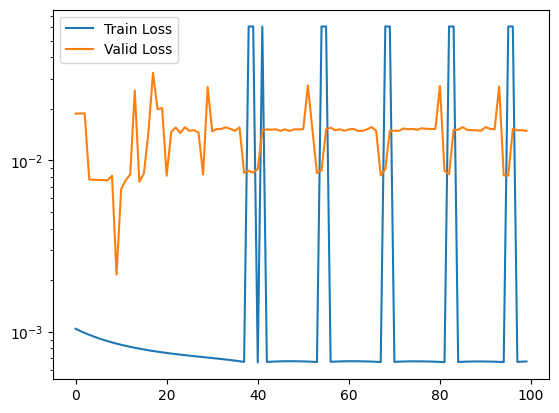

In [5]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [6]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
train = Dataset.load(train_file)
print(valid.idx_b)
print(valid.xb)
print(valid.lambdas)

total mass: 0.09071386584527141
[ 0  1  2  3  4  5  6  7 11 15 19 23 27 28 29 30 31 32 33 34]
[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  5.38724096e-01
    0.00000000e+00  3.98113936e-02]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  5.38724096e-01
    0.00000000e+00  3.98113936e-02]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  5.38724096e-01
    0.00000000e+00  3.98113936e-02]
  ...
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  4.13756457e-01
    0.00000000e+00  1.44474765e-01]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  4.02914196e-01
    0.00000000e+00  1.56561926e-01]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  3.91609065e-01
    0.00000000e+00  1.69103566e-01]]

 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  5.44560044e-01
    0.00000000e+00  2.72445117e-02]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  5.44560044e-01
    0.00000000e+00  2.72445117e-02]
  [ 0.00000000e+00  0.00000000e+00  0.0000

In [7]:

pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [8]:
animate(pred[0])

In [9]:
animate(valid.qs[0])

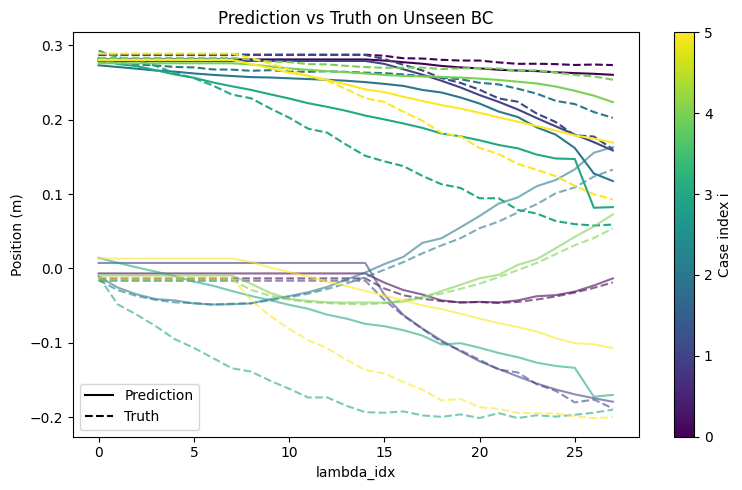

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

center_node = properties.N // 2

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4*center_node + 0], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4*center_node + 0], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 4*center_node + 2], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 4*center_node + 2], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

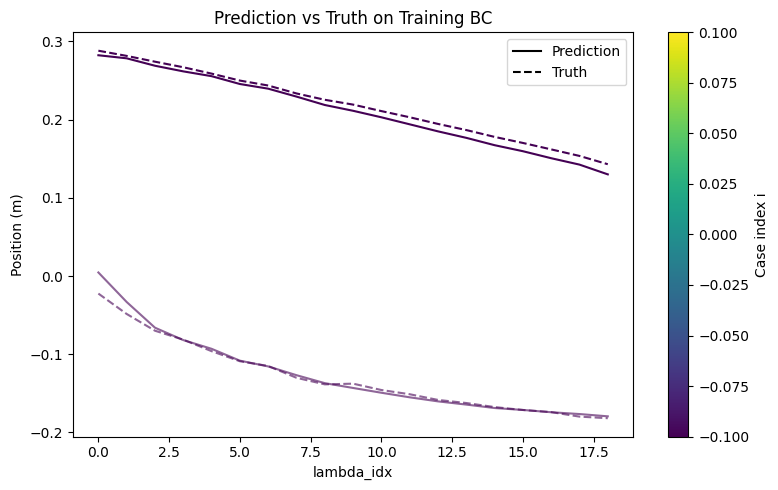

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp
pred = predict(final_model, base, aux, train.idx_b, train.xb, train.lambdas)
n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4*center_node + 0], color=c, linestyle='-')
    ax.plot(train.qs[i, :, 4*center_node + 0], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 4*center_node + 2], color=c, linestyle='-', alpha=0.6)
    ax.plot(train.qs[i, :, 4*center_node + 2], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Training BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

In [12]:
learned_K0 = final_model.get_K0()
print("Learned K0:", learned_K0)

Learned K0: [21.34715585  0.93875102]
